In [23]:
import spaTrack as spt
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
sc.settings.verbosity = 0

adata_all = sc.read_h5ad('/data/work/05.cluster/FuseMap/20250106/cerebellum_latent_embeddings_all_spatial_pretrain/dmt_leiden_20250108_1.h5ad')
adata_all = adata_all[:, ~adata_all.var_names.str.startswith('MT')]
adata_all = adata_all[:, ~adata_all.var_names.str.startswith('-')]
adata_all = adata_all[:, adata_all.var_names != '']
adata_all.obs_names_make_unique()
dmt_leiden_merge = {
    '0': 'Cebe_0',
    '8': 'Cebe_0',
    '44': 'Cebe_0',
    '32': 'Cebe_0',
    '15': 'Cebe_0',
    '20': 'Cebe_0',
    '13': 'Cebe_0',
    '3': 'Cebe_0',
    '24': 'Cebe_1',
    '27': 'Cebe_1',
    '7': 'Cebe_1',
    
    '16': 'Cebe_2',
    '10': 'Cebe_2',
    
    '30': 'Cebe_3',
    '35': 'Cebe_3',
    '1': 'Cebe_3',
    
    '17': 'Cebe_4',
    '36': 'Cebe_4',
    '28': 'Cebe_4',
    
    '5': 'Cebe_5',
    
    '31': 'Cebe_6',
    '33': 'Cebe_6',
    '11': 'Cebe_6',
    '22': 'Cebe_6',
    '41': 'Cebe_6',
    '21': 'Cebe_6',
    
    
    '37': 'Cebe_7',
    '25': 'Cebe_7',
    
    '45': 'Cebe_8',
    '34': 'Cebe_8',
    '18': 'Cebe_8',
    '38': 'Cebe_8',
    '9': 'Cebe_8',
    '4': 'Cebe_8',
    '19': 'Cebe_8',
    '26': 'Cebe_8',
    
    '43': 'z_delete',
    
    '6': 'Cebe_9',
    '12': 'Cebe_9',
    '14': 'Cebe_9',
    '2': 'Cebe_9',
    '29': 'Cebe_9',
    
    '23': 'Cebe_10',
    '39': 'Cebe_10',
    '42': 'Cebe_10',
    
    '40': 'Cebe_11',

}
adata_all.obs['dmt_leiden_anno'] = [dmt_leiden_merge[i] for i in adata_all.obs['dmt_leiden'] ]
adata_all = adata_all[adata_all.obs['dmt_leiden_anno']!='z_delete']

/opt/software/python/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning:

Observation names are not unique. To make them unique, call `.obs_names_make_unique`.



In [ ]:
# adata_all = adata_all[adata_all.obs.sample(frac = 0.1).index].copy()

In [25]:
import numpy as np
from scipy.stats import entropy
from scipy.sparse import issparse

def assess_start_cluster(adata, obs_key):
    X = adata.X
    if issparse(X):
        entropy_list = np.array([entropy(row.data) if len(row.data) > 0 else 0.0 for row in X])
    else:
        entropy_list = np.array([entropy(row) for row in X])

    adata.obs['entropy'] = entropy_list

    # 按 cluster 平均熵排序
    entropy_by_cluster = adata.obs.groupby(obs_key)['entropy'].mean().sort_values(ascending=False)
    cluster_order = entropy_by_cluster.index.tolist()

    # 设置 categorical order
    adata.obs[obs_key] = pd.Categorical(adata.obs[obs_key], categories=cluster_order, ordered=True)

    # 保存结果
    adata.uns['entropy_value'] = adata.obs
    adata.uns['entropy_value_order'] = entropy_by_cluster

    print('Cluster order sorted by entropy value:', cluster_order)
    return adata

In [19]:
adata = assess_start_cluster(adata_all, 'dmt_leiden_anno')

/tmp/ipykernel_706/3077110064.py:12: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



Cluster order sorted by entropy value: ['Cere_sc_11', 'Cere_sc_4', 'Cere_sc_13', 'Cere_sc_5', 'Cere_sc_9', 'Cere_sc_3', 'Cere_sc_6', 'Cere_sc_1', 'Cere_sc_20', 'Cere_sc_14', 'Cere_sc_17', 'Cere_sc_15', 'Cere_sc_2', 'Cere_sc_12', 'Cere_sc_10', 'Cere_sc_19', 'Cere_sc_16', 'Cere_sc_18', 'Cere_sc_21', 'Cere_sc_7', 'Cere_sc_22', 'Cere_sc_8']


In [26]:
adata = assess_start_cluster(adata_all, 'dmt_leiden_anno')

/tmp/ipykernel_706/3077110064.py:12: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



Cluster order sorted by entropy value: ['Cebe_0', 'Cebe_5', 'Cebe_3', 'Cebe_6', 'Cebe_2', 'Cebe_10', 'Cebe_8', 'Cebe_4', 'Cebe_11', 'Cebe_1', 'Cebe_9', 'Cebe_7']


In [27]:
1

1

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


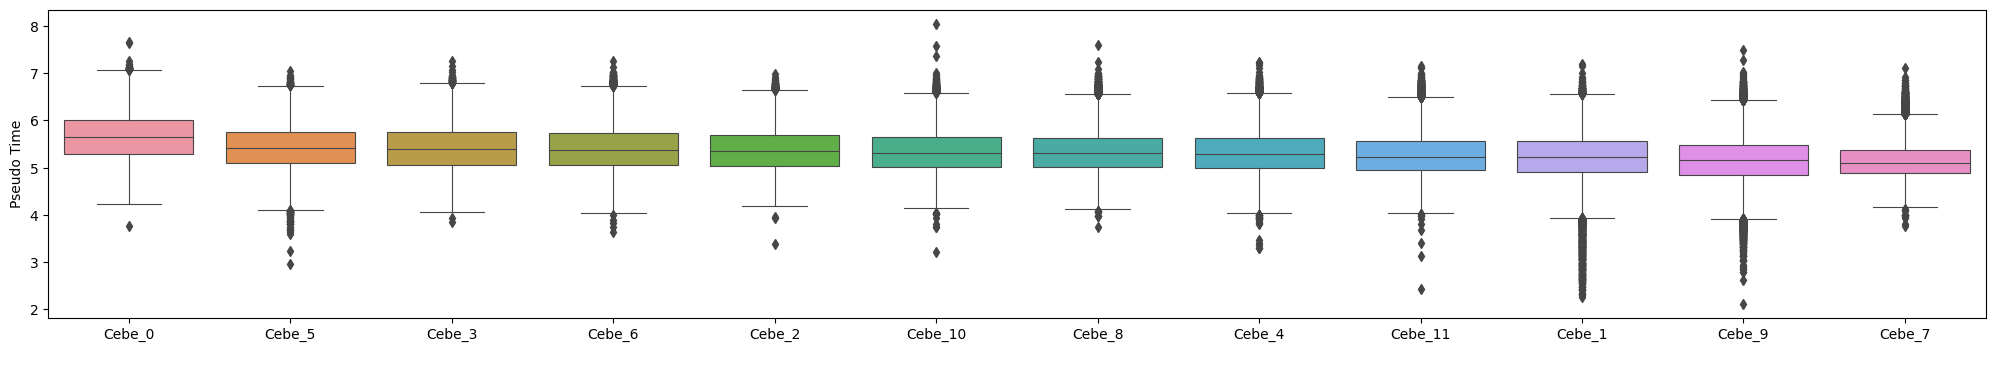

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
plt.figure(figsize=(25, 4))

ax = sns.boxplot(
    data=adata.obs,
    x='dmt_leiden_anno',
    y='entropy',
    # hue='gws',
    linewidth=0.8,
    # palette=colormap,  # 这里可以注释掉，因为我们手动管理颜色
    # order=[ 'Cebe_7', 'Cebe_8', 'Cebe_5','Cebe_0','Cebe_6', 'Cebe_1', 'Cebe_4', 'Cebe_2', 'Cebe_3',],
    # showfliers=False
)
ax.set_xlabel(' ')
ax.set_ylabel('Pseudo Time')
ax.legend(frameon=False)
# plt.savefig('/data/work/05.cluster/FuseMap/0314/tracks/Pseudo_Time.pdf', bbox_inches = 'tight')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


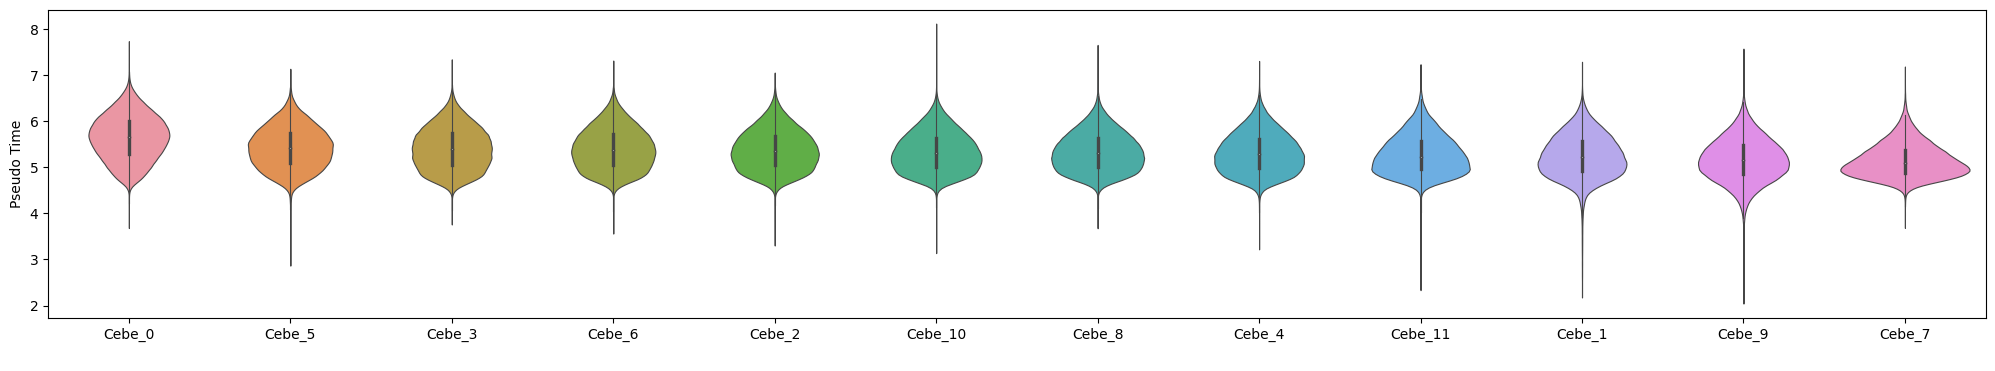

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
plt.figure(figsize=(25, 4))

ax = sns.violinplot(
    data=adata.obs,
    x='dmt_leiden_anno',
    y='entropy',
    # hue='gws',
    linewidth=0.8,
    # palette=colormap,  # 这里可以注释掉，因为我们手动管理颜色
    # order=[ 'Cebe_7', 'Cebe_8', 'Cebe_5','Cebe_0','Cebe_6', 'Cebe_1', 'Cebe_4', 'Cebe_2', 'Cebe_3',],
    # showfliers=False
)
ax.set_xlabel(' ')
ax.set_ylabel('Pseudo Time')
ax.legend(frameon=False)
# plt.savefig('/data/work/05.cluster/FuseMap/0314/tracks/Pseudo_Time.pdf', bbox_inches = 'tight')
plt.show()

In [ ]:
1

In [ ]:
11

In [ ]:
11

In [ ]:
1